<div class="alert alert-block alert-info" style="padding:20px;color:white;margin:auto;font-size:300%;text-align:center;display:fill;border-radius:60px;background-color:#37006f;overflow:hidden;font-weight:800">Text to Midi</div>

This notebooks tackle an approach for generating a MIDI file based on caption provided to the model.

## 1. Setup

In [1]:
cd ..

d:\Personal Projects\tune-ml


d:\Personal Projects\tune-ml\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# imports
from tuneml.data.midicap import MidiCapDataset

d:\Personal Projects\tune-ml\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:8080")
mlflow.set_experiment("Midi Generation")

# Enable system metrics logging
mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)  # Log system metrics every 1 second

## 2. Data Processing

In [ ]:
dataset = MidiCapDataset("datasets/midicaps/train.json", n_samples=10000)
print(f"Dataset size: {len(dataset)}")
print(f"Example MIDI shape: {dataset.midi[0].shape}")

MIDI shape: torch.Size([10000, 2048])
Text shape: torch.Size([10000, 256])
Dataset size: 10000
Example MIDI shape: torch.Size([2048])


## 3. Model Training

In [ ]:
# Hyperparameters
datapath = "datasets/midicaps/train.pt"
batch_size = 8
warmup_steps = 2000
ckpt_path = "./weights/midi_transformer_ckpt_2.pt"
load_checkpoint = False
save_path = "./weights/midi_transformer_model_2.pt"
num_epochs = 10
hparams = {
    "d_model": 512,
    "num_layers": 6,
    "num_heads": 8,
    "d_ff": 512,
    "max_midi_len": 2048,
    "max_text_len": 512,
    "bias": True,
    "dropout": 0.1,
    "layernorm_eps": 1e-6,
}

In [ ]:
import torch
from datetime import datetime
from tuneml.trainers.MidiTransformerTrainer import MidiTransformerTrainer

# set up the trainer
print("Setting up the trainer...")
trainer = MidiTransformerTrainer(
    hparams,
    datapath,
    batch_size,
    warmup_steps,
    ckpt_path,
    load_checkpoint,
    n_samples=1000,
    mlflow_enabled=True,
    mlflow_log_model=True
 )
print()

# train the model
run_name = "model_training_" + datetime.now().strftime("%Y%m%d_%H%M%S")
with mlflow.start_run(run_name=run_name):
    try:
        trainer.fit(num_epochs)
    except Exception as e:
        print(f"Error occurred during training: {e}")

# done training, save the model
print("Saving...")
save_file = {
    "state_dict": trainer.model.state_dict(),
    "hparams": trainer.hparams
}
torch.save(save_file, save_path)
print("Done!")

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


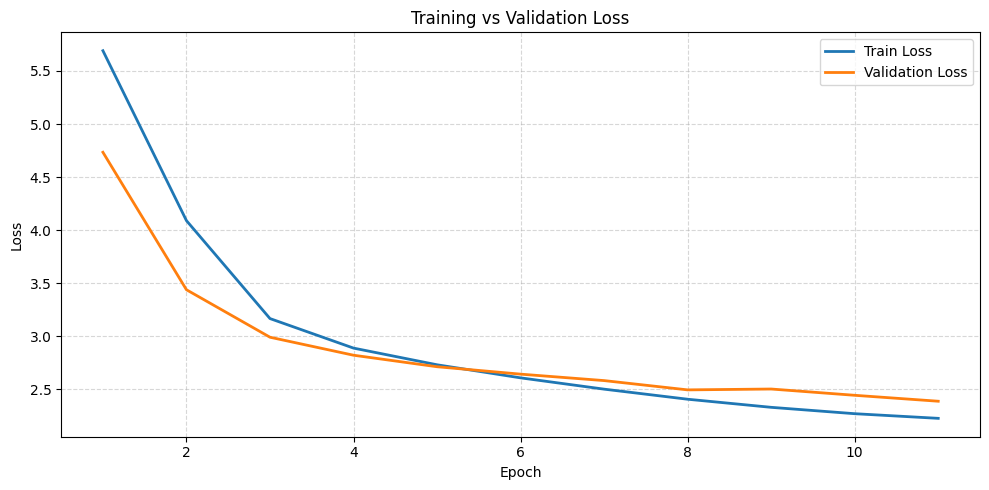

In [ ]:
import matplotlib.pyplot as plt

train_losses = list(getattr(trainer, "train_losses", []))
val_losses = list(getattr(trainer, "val_losses", []))

if not train_losses or not val_losses:
    raise ValueError("No training history found. Run trainer.fit(...) before plotting.")

epochs = range(1, min(len(train_losses), len(val_losses)) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses[:len(epochs)], label="Train Loss", linewidth=2)
plt.plot(epochs, val_losses[:len(epochs)], label="Validation Loss", linewidth=2)
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Model Evaluation

In [2]:
from tuneml.modules.generator.MidiGenerator import MidiGenerator

d:\Personal Projects\tune-ml\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# set up the generator with the best model
model_ckpt_path = "./weights/midi_transformer_model_2.pt"
generator = MidiGenerator(model_ckpt_path=model_ckpt_path)

CUDA is not available, falling back to CPU


d:\Personal Projects\tune-ml\tuneml\tokenizers\MidiTokenizer.py:57: UserWarning: Attribute controls are not compatible with 'config.one_token_stream_for_programs' and multi-vocabulary tokenizers. Disabling them from the config.
  self.tokenizer = Structured(config)


In [7]:
# generate a happy MIDI from text
midi_tokens = generator(
    "A slow relaxing and happy melody with a steady rhythm, perfect for a sunny day at the beach.",
    temperature=1
)

In [8]:
# convert the generated MIDI tokens back to a MIDI file
generator.tokens_to_midi(
    tokens=midi_tokens,
    store_path="./tests/midi_transformer_generated_melod_10.mid"
)